# Conservation of Physical quantities and convergence of integrators

This notebook compares the conservation plots of energy and angular momentum in Euler and Leapfrog integrators as well as their convergence.

## Conservation
In planetary simulations, conservation refers to the ability of a numerical method to preserve important physical quantities such as total energy and angular momentum throughout the motion.
The total mechanical energy of the system is given by:
$$
E = \frac12 mv^2 - \frac{GMm}{r}
$$
Angular momentum is given by:
$$
\vec{L} = \vec{r} \times m\vec{v}
$$
Since gravity acts as a central force, angular momentum should remain constant throughout the orbit.

## Conservation in Euler Integrator
The Euler integrator does not conserve energy and angular momentum very well. Small numerical errors are introduced at every timestep, and these errors gradually accumulate during the simulation.
Because of this:
- total energy slowly changes,
- angular momentum drifts,
- the orbit becomes unstable.
The planet eventually spirals outward or inward instead of maintaining a stable orbit.

## Conservation in Leapfrog Integrator
The Leapfrog integrator conserves physical quantities much more effectively. It updates position and velocity in separate half-steps, which greatly reduces numerical error.
As a result:
- total energy remains nearly constant,
- angular momentum stays almost unchanged,
- the orbit remains stable over long periods of time.
Only very small oscillations appear in the graphs, which are normal numerical fluctuations.



In [1]:
#Necessary Libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Circle
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
print("Libraries have been imported")

#Constants
G = 6.67430e-11          # Gravitational constant
M = 1.989e30             # Mass of Sun
R = 6.957e8              # Radius of Sun
AU = 1.496e11            # Astronomical Unit
N_steps = 250
print("Constants have been set")

#Standardizations
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,})
# ------------------------------------------------- #
positions = np.zeros((N_steps, 2))
velocities = np.zeros((N_steps, 2))
times = np.zeros(N_steps)
energies = np.zeros(N_steps)
print("Standardizations have been set")

Libraries have been imported
Constants have been set
Standardizations have been set


In [2]:
#Core Physical Functions
def gravitational_force(r, m1, m2):
  r_mag = np.linalg.norm(r)
  return -G * m1 * m2 * r / r_mag**3

def gravitational_potential(r, m1, m2):
    r_mag = np.linalg.norm(r)
    return -G * m1 * m2 / r_mag

def gravitational_acceleration(r):
  r_mag = np.linalg.norm(r)
  if r_mag < 1e-10:      # To avoid singularity at origin
        raise ValueError("Planet has reached the star — simulation invalid.")
  return -G*M / r_mag**3 * r

def kinetic_energy(m, v):
    return 0.5 * m * np.dot(v, v)
def total_energy(m, r, v):
    r_mag = np.linalg.norm(r)
    return 0.5 * m * np.dot(v, v) - (G * M) / r_mag
def angular_momentum(m, r, v):
    return m * np.cross(r, v)

print("All functions have been defined")

All functions have been defined


In [3]:
# Initial conditions
x0 = AU
y0 = 0

vx0 = 0
vy0 = 29780

# Time settings
dt = 24 * 3600
N_steps = 2500

# EULER

x = x0
y = y0

vx = vx0
vy = vy0

energy_euler = []
momentum_euler = []
time_points = []

for step in range(N_steps):

    r = np.sqrt(x**2 + y**2)

    # Acceleration
    ax = -G * M * x / r**3
    ay = -G * M * y / r**3

    # Euler update
    x = x + vx * dt
    y = y + vy * dt

    vx = vx + ax * dt
    vy = vy + ay * dt

    # Energy
    v2 = vx**2 + vy**2

    K = 0.5 * v2
    U = -G * M / r

    E = K + U

    energy_euler.append(E)

    # Angular momentum
    L = x * vy - y * vx

    momentum_euler.append(L)

    time_points.append(step)

In [4]:
# LEAPFROG

x = x0
y = y0

vx = vx0
vy = vy0

energy_leapfrog = []
momentum_leapfrog = []

# Initial acceleration
r = np.sqrt(x**2 + y**2)

ax = -G * M * x / r**3
ay = -G * M * y / r**3

for step in range(N_steps):

    # Half-step velocity
    vx_half = vx + 0.5 * ax * dt
    vy_half = vy + 0.5 * ay * dt

    # Position update
    x = x + vx_half * dt
    y = y + vy_half * dt

    # New distance
    r = np.sqrt(x**2 + y**2)

    # New acceleration
    ax_new = -G * M * x / r**3
    ay_new = -G * M * y / r**3

    # Final velocity update
    vx = vx_half + 0.5 * ax_new * dt
    vy = vy_half + 0.5 * ay_new * dt

    # Store acceleration
    ax = ax_new
    ay = ay_new

    # Energy
    v2 = vx**2 + vy**2

    K = 0.5 * v2
    U = -G * M / r

    E = K + U

    energy_leapfrog.append(E)

    # Angular momentum
    L = x * vy - y * vx

    momentum_leapfrog.append(L)

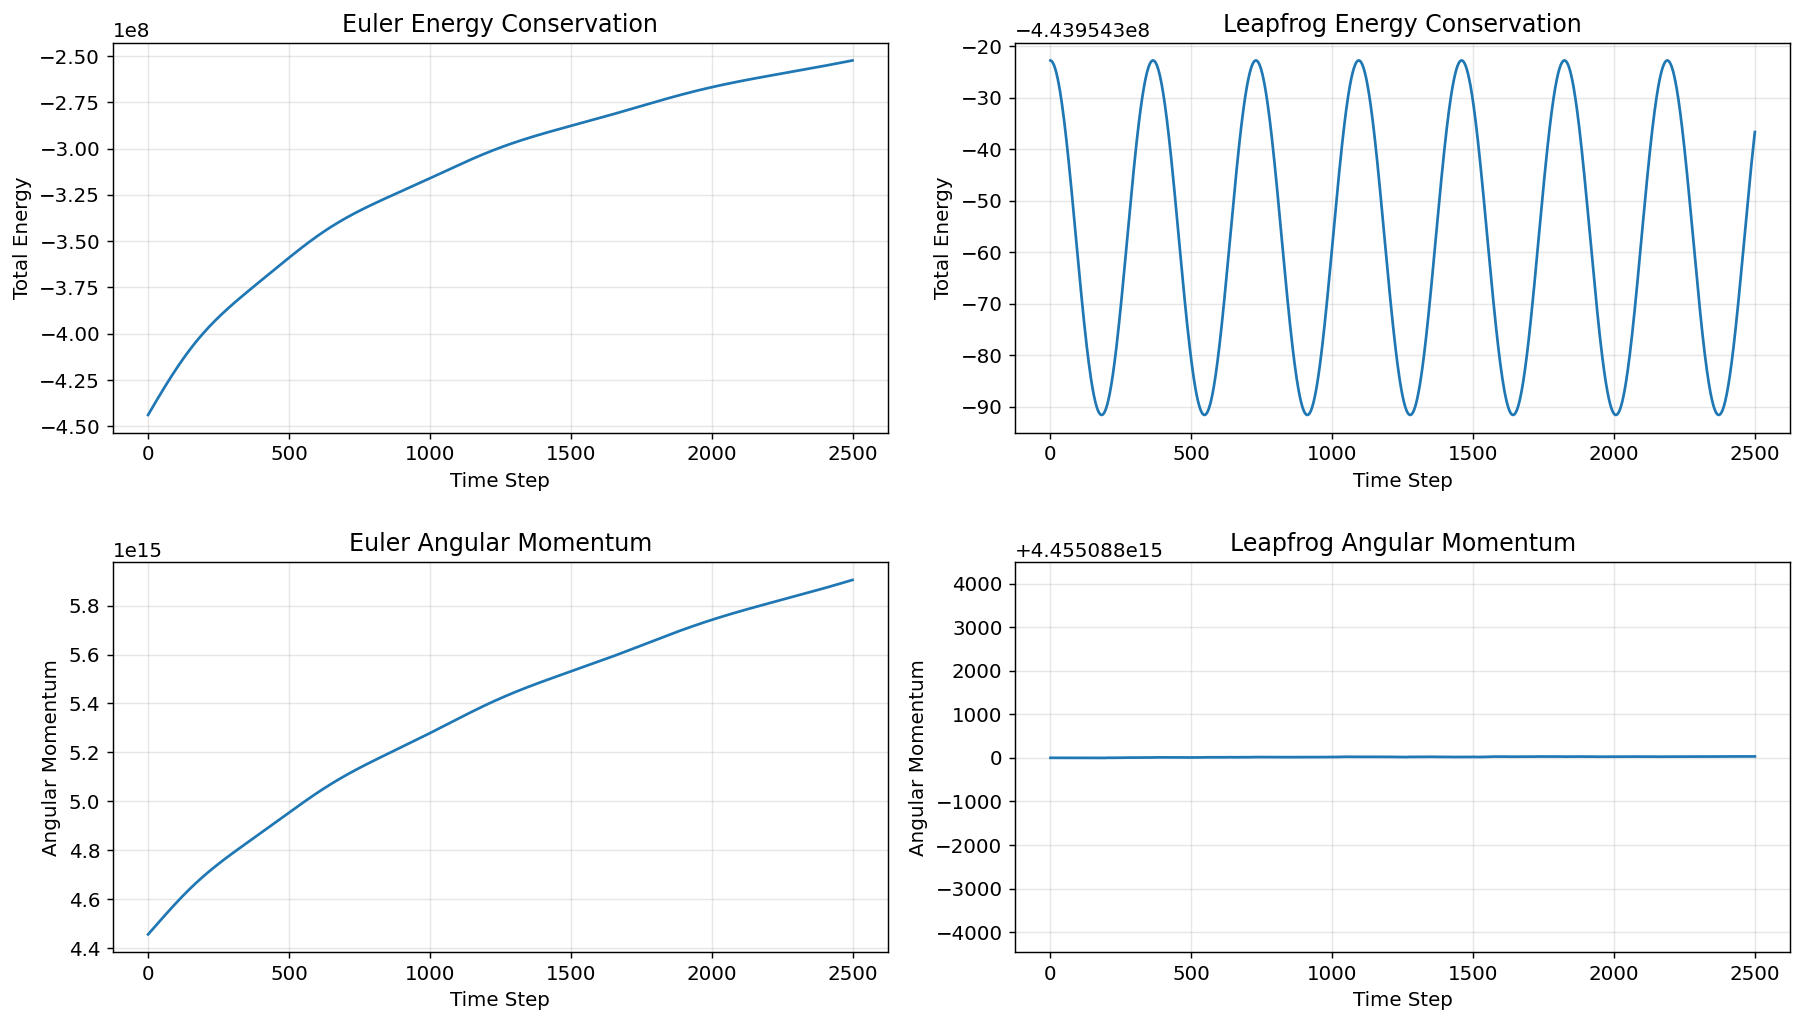

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(14,8))

# Euler Energy
ax[0,0].plot(time_points, energy_euler)

ax[0,0].set_title("Euler Energy Conservation")
ax[0,0].set_xlabel("Time Step")
ax[0,0].set_ylabel("Total Energy")

ax[0,0].grid(True)

# Leapfrog Energy
ax[0,1].plot(time_points, energy_leapfrog)

ax[0,1].set_title("Leapfrog Energy Conservation")
ax[0,1].set_xlabel("Time Step")
ax[0,1].set_ylabel("Total Energy")

ax[0,1].grid(True)

# Euler Angular Momentum
ax[1,0].plot(time_points, momentum_euler)

ax[1,0].set_title("Euler Angular Momentum")
ax[1,0].set_xlabel("Time Step")
ax[1,0].set_ylabel("Angular Momentum")

ax[1,0].grid(True)

# Leapfrog Angular Momentum
ax[1,1].plot(time_points, momentum_leapfrog)

ax[1,1].set_title("Leapfrog Angular Momentum")
ax[1,1].set_xlabel("Time Step")
ax[1,1].set_ylabel("Angular Momentum")

ax[1,1].grid(True)

plt.tight_layout()

plt.show()

# Difference Between the Euler and Leapfrog Results
The graphs clearly show how the two integration methods behave differently during the simulation of planetary motion.

## Euler Integrator Results:
In the Euler method, both the energy and angular momentum graphs increase steadily with time instead of remaining constant.

### Energy Graph
The energy graph shows a continuous upward drift, meaning the system is gradually gaining extra artificial energy during the simulation.
As this energy increases:
- the planet moves faster,
- the orbit becomes larger,
- the planet slowly spirals outward.
This is not physically accurate because, in a real planetary system, total energy should remain constant.

### Angular Momentum Graph
The angular momentum graph also rises continuously instead of staying flat.
This shows that the Euler method is unable to conserve angular momentum properly. Small numerical errors are introduced at every timestep, and these errors build up over time.
Because of this:
- the orbit becomes unstable,
- the motion becomes distorted,
- the simulation becomes less realistic over long periods.
Overall, the Euler integrator produces unstable results because numerical errors continuously accumulate during the simulation.

## Leapfrog Integrator Results:
The Leapfrog method produces much more stable and realistic results.

### Energy Graph
Unlike the Euler graph, the Leapfrog energy graph does not drift continuously upward or downward. Instead, it oscillates slightly around a nearly constant value.
These small oscillations are normal numerical fluctuations and are much smaller than the large drift seen in the Euler method.
This means:
- total energy is conserved very well,
- the orbit remains stable,
- the simulation stays physically realistic.

### Angular Momentum Graph
The angular momentum graph is almost perfectly horizontal, showing that angular momentum remains nearly constant throughout the simulation.
This indicates that the Leapfrog method preserves rotational motion very accurately and prevents errors from accumulating significantly over time.
As a result:
- the orbit remains stable,
- the motion stays realistic,
- long-term accuracy is much better.


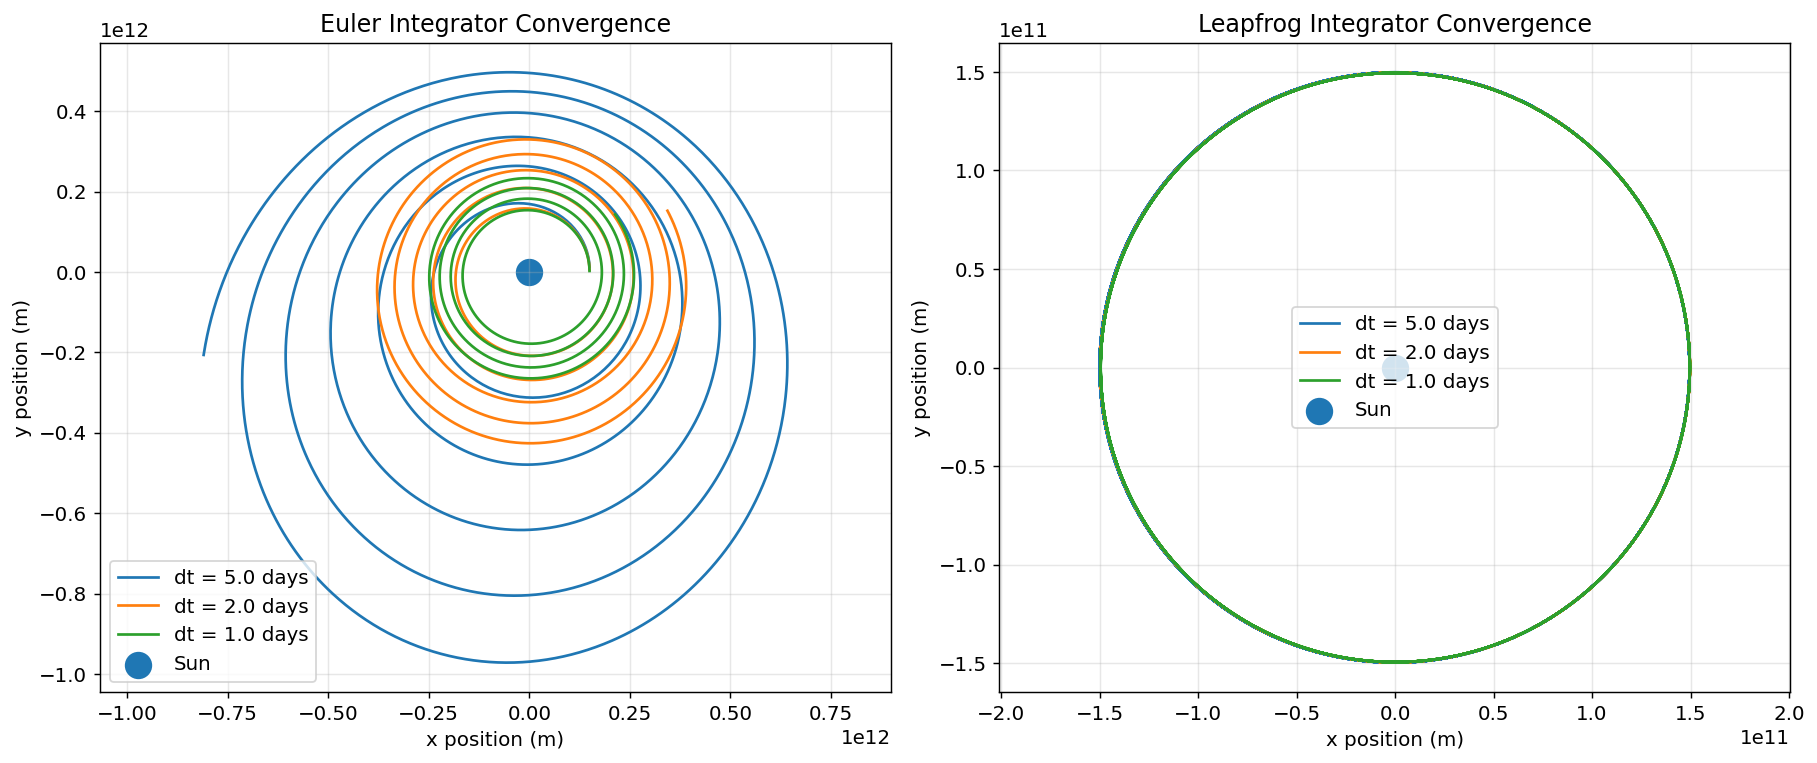

In [6]:
# Different timesteps
dt_values = [5*24*3600, 2*24*3600, 1*24*3600]

# Create side-by-side plots
fig, ax = plt.subplots(1, 2, figsize=(14,6))

# EULER

for dt in dt_values:

    # Initial conditions
    x = AU
    y = 0

    vx = 0
    vy = 29780

    N_steps = 2500

    x_points = []
    y_points = []

    # Euler loop
    for step in range(N_steps):

        r = np.sqrt(x**2 + y**2)

        ax_e = -G * M * x / r**3
        ay_e = -G * M * y / r**3

        # Euler update
        x = x + vx * dt
        y = y + vy * dt

        vx = vx + ax_e * dt
        vy = vy + ay_e * dt

        x_points.append(x)
        y_points.append(y)

    ax[0].plot(x_points, y_points,
               label=f"dt = {dt/(24*3600)} days")

# Sun
ax[0].scatter(0, 0, s=200, label="Sun")

ax[0].set_xlabel("x position (m)")
ax[0].set_ylabel("y position (m)")

ax[0].set_title("Euler Integrator Convergence")

ax[0].axis("equal")
ax[0].legend()

# LEAPFROG

for dt in dt_values:

    # Initial conditions
    x = AU
    y = 0

    vx = 0
    vy = 29780

    N_steps = 2500

    x_points = []
    y_points = []

    # Initial acceleration
    r = np.sqrt(x**2 + y**2)

    ax_l = -G * M * x / r**3
    ay_l = -G * M * y / r**3

    # Leapfrog loop
    for step in range(N_steps):

        # Half-step velocity
        vx_half = vx + 0.5 * ax_l * dt
        vy_half = vy + 0.5 * ay_l * dt

        # Position update
        x = x + vx_half * dt
        y = y + vy_half * dt

        # New distance
        r = np.sqrt(x**2 + y**2)

        # New acceleration
        ax_new = -G * M * x / r**3
        ay_new = -G * M * y / r**3

        # Final velocity update
        vx = vx_half + 0.5 * ax_new * dt
        vy = vy_half + 0.5 * ay_new * dt

        # Store acceleration
        ax_l = ax_new
        ay_l = ay_new

        x_points.append(x)
        y_points.append(y)

    ax[1].plot(x_points, y_points,
               label=f"dt = {dt/(24*3600)} days")

# Sun
ax[1].scatter(0, 0, s=200, label="Sun")

ax[1].set_xlabel("x position (m)")
ax[1].set_ylabel("y position (m)")

ax[1].set_title("Leapfrog Integrator Convergence")

ax[1].axis("equal")
ax[1].legend()

# Layout
plt.tight_layout()

plt.show()

# Difference Between Euler and Leapfrog Convergence Results
The convergence graphs show how the accuracy of the simulation changes when different timestep sizes are used.
A numerical method is said to converge if the simulated orbit becomes closer to the true physical orbit as the timestep becomes smaller.

## Euler Integrator Results
In the Euler integrator convergence graph, the orbits change significantly when different timestep values are used.

### Observations
- Large timesteps produce highly distorted orbits.
- The orbit spirals outward quickly.
- Different timestep values give noticeably different results.
- The simulation becomes unstable over time.

### Explanation
The Euler method introduces numerical errors at every timestep. When the timestep is large, these errors become much larger and accumulate rapidly.
Because of this:
- energy is not conserved properly,
- angular momentum drifts,
- the orbit becomes unrealistic.
Reducing the timestep improves the orbit slightly, but errors still continue to build up over long simulations.

### Conclusion
The Euler method converges slowly and requires very small timesteps to produce acceptable accuracy.

## Leapfrog Integrator Results
In the Leapfrog convergence graph, the orbits remain much more stable even when larger timesteps are used.

### Observations
- The orbits remain nearly circular.
- Different timestep values produce very similar results.
- The simulation stays stable over long periods.
- Only small deviations appear for larger timesteps.

### Explanation
The Leapfrog method reduces numerical error by updating position and velocity in separate half-steps.
Because of this:
- energy remains nearly constant,
- angular momentum is conserved well,
- errors do not accumulate rapidly.
As the timestep becomes smaller, the simulated orbit approaches the true orbital motion very closely.

### Conclusion
The Leapfrog integrator converges much faster and more accurately than the Euler method.

